<a href="https://colab.research.google.com/github/RolandoLopez16/RegresionLinealHV/blob/main/RegresionLinealHV_v15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de regresión lineal para productividad de equipos Harvester

**Trabajo final de especialización — Analítica de datos aplicada a operación forestal**

Este notebook desarrolla un flujo completo, reproducible y documentado para estimar la productividad operacional `M3/HORA` de equipos harvester. El proceso se estructura en el mismo orden lógico del proyecto académico: carga del dataset, enriquecimiento climático por coordenadas, control de calidad de datos, tratamiento de valores extremos del objetivo mediante `KNNImputer`, preparación de variables, entrenamiento de regresión lineal, validación cruzada y análisis de resultados.

El modelo final conserva el enfoque metodológico definido para el trabajo: **aprendizaje supervisado**, **regresión lineal** y **transformación de variables categóricas mediante One-Hot Encoding**. Adicionalmente, se incluye una evaluación técnica sobre la agrupación de categorías raras antes del One-Hot Encoding. En las pruebas realizadas con este dataset, la agrupación no mejoró el R²; por tanto, el modelo final mantiene las categorías originales para no perder información explicativa.

## 1. Librerías y configuración general

Esta sección importa las librerías necesarias para manipulación de datos, consulta climática, visualización, imputación, modelado y validación. El notebook está preparado para ejecutarse tanto en Google Colab como en un entorno local. Si `meteostat` no está disponible, el flujo continúa usando Open-Meteo y NASA POWER como fuentes climáticas principales.

In [7]:
# ============================================================
# 1. LIBRERÍAS Y CONFIGURACIÓN GENERAL
# ============================================================

import os
import re
import time
import json
import math
import warnings
from pathlib import Path
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_STATE = 42
TEST_SIZE = 0.20
K_FOLDS = 10
TIMEOUT_API_SEGUNDOS = 30
UMBRAL_MAX_FALTANTES_CLIMA = 100
KNN_VECINOS_TARGET = 7

# En Colab puede dejarse True para consultar datos climáticos externos.
# Si no hay internet, el notebook no falla: registra la ausencia de clima y sigue con variables operacionales.
CONSULTAR_CLIMA_EXTERNO = True
PAUSA_ENTRE_CONSULTAS = 0.15

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Configuración cargada correctamente.")
print("Directorio de salida:", OUTPUT_DIR.resolve())

Configuración cargada correctamente.
Directorio de salida: /content/outputs


## 2. Carga robusta del dataset

La carga conserva la lógica solicitada para el proyecto: primero busca el archivo en rutas frecuentes de Colab y entornos locales; si no lo encuentra, permite cargarlo manualmente desde el explorador de archivos de Colab.

In [8]:
# ============================================================
# 2. CARGA ROBUSTA DEL DATASET
# ============================================================

FILE_NAME = "Dataset_HV_2026_v5.xlsx"
SHEET_NAME = "INFORMEHV"

possible_paths = [
    Path("/mnt/data") / FILE_NAME,
    Path("/content") / FILE_NAME,
    Path.cwd() / FILE_NAME,
    Path(".") / FILE_NAME,
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print("No se encontró el archivo localmente. Seleccione el archivo Dataset_HV_2026_v3.xlsx.")
        uploaded = files.upload()
        if FILE_NAME in uploaded:
            DATA_PATH = Path("/content") / FILE_NAME
        else:
            DATA_PATH = Path("/content") / next(iter(uploaded.keys()))
    except Exception as exc:
        raise FileNotFoundError(
            f"No se encontró {FILE_NAME}. Coloque el archivo en el mismo directorio del notebook o en /content."
        ) from exc

print(f"Archivo utilizado: {DATA_PATH}")
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]:,} columnas")
display(df_raw.head())

Archivo utilizado: /content/Dataset_HV_2026_v5.xlsx
Dataset cargado: 1,990 filas x 66 columnas


,E%,E% Global,DM%,ARB/HORA,VOL/ÁRBOL,PRODUCTIVIDAD M3/H,T EFECTIVO,Horas disponibles,Ttal P. mec,Mantenimiento periódico,...,T OTRA PARADA3,T OTRA PARADA 4,T OTRA PARADA 5,MOTIVO 1,MOTIVO 2,MOTIVO 3,MOTIVO 4,MOTIVO 5,Unnamed: 64,Unnamed: 65
0,0.882353,0.625000,0.708333,28.53,0.31,8.93,7.50,8.50,3.50,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.806452,0.312500,0.387500,19.20,0.10,2.00,2.50,3.10,4.90,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.943421,0.896250,0.950000,42.68,0.25,10.47,7.17,7.60,0.40,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.000000,0.853750,0.853750,16.54,0.36,5.96,6.83,6.83,1.17,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.971698,0.792308,0.815385,21.75,0.54,11.70,5.15,5.30,1.20,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Definición de variables del proyecto

La variable objetivo es `M3/HORA`, que representa la productividad operacional del equipo. Las variables explicativas se dividen en dos grupos: variables numéricas operacionales y variables categóricas. Las variables climáticas se incorporan únicamente si se recuperan datos reales suficientes o si cumplen la regla de imputación controlada.

In [9]:
# ============================================================
# 3. DEFINICIÓN DE VARIABLES
# ============================================================

target = "M3/HORA"

variables_categoricas = [
    "EQUIPO",
    "MARCA",
    "ZONA",
    "CONTRATISTA",
    "ESPECIE",
    "TURNO",
    "SUELO",
]

variables_numericas_operacionales = [
    "PENDIENTE PROMEDIO FINCA",
    "TOTAL DE ARBOLES",
    "DIAMETRO",
    "T PROGRAMADO",
    "HORAS DE OTRAS PARADA",
]

variables_climaticas = [
    "clima_temp_promedio_dia_c",
    "clima_temp_min_dia_c",
    "clima_temp_max_dia_c",
    "clima_precipitacion_dia_mm",
    "clima_viento_promedio_dia_kmh",
    "clima_presion_promedio_dia_hpa",
]

columnas_requeridas = variables_categoricas + variables_numericas_operacionales + [
    target,
    "FECHA",
    "Longitud Sexa finca",
    "Latitud Sexa finca",
    "Municipio Finca",
]

columnas_faltantes = [c for c in columnas_requeridas if c not in df_raw.columns]
if columnas_faltantes:
    raise ValueError(f"Faltan columnas requeridas en el dataset: {columnas_faltantes}")

print("Variable objetivo:", target)
print("Variables numéricas operacionales:")
display(variables_numericas_operacionales)
print("Variables categóricas:")
display(variables_categoricas)
print("Variables climáticas candidatas:")
display(variables_climaticas)

Variable objetivo: M3/HORA
Variables numéricas operacionales:


['PENDIENTE PROMEDIO FINCA',
 'TOTAL DE ARBOLES',
 'DIAMETRO',
 'T PROGRAMADO',
 'HORAS DE OTRAS PARADA']

Variables categóricas:


['EQUIPO', 'MARCA', 'ZONA', 'CONTRATISTA', 'ESPECIE', 'TURNO', 'SUELO']

Variables climáticas candidatas:


['clima_temp_promedio_dia_c',
 'clima_temp_min_dia_c',
 'clima_temp_max_dia_c',
 'clima_precipitacion_dia_mm',
 'clima_viento_promedio_dia_kmh',
 'clima_presion_promedio_dia_hpa']

## 4. Comprensión inicial del dataset

Antes de transformar los datos, se revisan dimensiones, tipos de datos, periodo de análisis y completitud. Esta auditoría permite justificar las decisiones de limpieza y preparación posteriores.

In [10]:
# ============================================================
# 4. AUDITORÍA INICIAL DEL DATASET
# ============================================================

df = df_raw.copy()

resumen_columnas = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": [str(df[c].dtype) for c in df.columns],
    "nulos": [int(df[c].isna().sum()) for c in df.columns],
    "porcentaje_nulos": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    "valores_unicos": [int(df[c].nunique(dropna=True)) for c in df.columns],
})

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

fecha_min = pd.to_datetime(df["FECHA"], errors="coerce").min()
fecha_max = pd.to_datetime(df["FECHA"], errors="coerce").max()
print(f"Periodo de análisis: {fecha_min.date()} a {fecha_max.date()}")

display(resumen_columnas.sort_values("porcentaje_nulos", ascending=False).head(20))

print("Resumen de la variable objetivo antes del tratamiento:")
display(pd.to_numeric(df[target], errors="coerce").describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame(target))

Filas: 1,990
Columnas: 66
Periodo de análisis: 2026-01-01 a 2026-05-15


,columna,tipo_dato,nulos,porcentaje_nulos,valores_unicos
27,clima_horas_lluvia_dia,float64,1990,100.00,0
26,clima_horas_validas_dia,float64,1990,100.00,0
63,MOTIVO 5,float64,1990,100.00,0
64,Unnamed: 64,float64,1990,100.00,0
25,clima_presion_promedio_dia_hpa,float64,1990,100.00,0
24,clima_viento_promedio_dia_kmh,float64,1990,100.00,0
22,clima_temp_max_dia_c,float64,1990,100.00,0
23,clima_precipitacion_dia_mm,float64,1990,100.00,0
20,clima_temp_promedio_dia_c,float64,1990,100.00,0
21,clima_temp_min_dia_c,float64,1990,100.00,0


Resumen de la variable objetivo antes del tratamiento:


,M3/HORA
count,1582.000000
mean,30.197630
std,529.614091
min,0.000000
1%,1.472900
5%,4.486000
25%,9.035000
50%,13.015000
75%,18.802500
95%,29.698000


## 5. Conversión de coordenadas y creación de llaves climáticas

El dataset contiene coordenadas en formato sexagesimal. Para consultar clima histórico externo, se convierten a coordenadas decimales y se construye una llave compuesta por latitud, longitud y fecha. Esta llave permite unir los datos climáticos reales al registro operacional correspondiente.

In [11]:
# ============================================================
# 5. CONVERSIÓN DE COORDENADAS Y LLAVES CLIMÁTICAS
# ============================================================

def dms_a_decimal(valor):
    """Convierte coordenadas sexagesimales a formato decimal."""
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip().upper()
    signo = -1 if any(h in texto for h in ["W", "S", "O"]) else 1
    nums = re.findall(r"[-+]?\d+(?:\.\d+)?", texto)
    if not nums:
        return np.nan
    try:
        grados = float(nums[0])
        minutos = float(nums[1]) if len(nums) > 1 else 0.0
        segundos = float(nums[2]) if len(nums) > 2 else 0.0
        return signo * (grados + minutos / 60 + segundos / 3600)
    except Exception:
        return np.nan


def normalizar_texto_categoria(valor):
    """Normaliza texto categórico sin perder significado operativo."""
    if pd.isna(valor):
        return "SIN_DATO"
    texto = str(valor).strip().upper()
    texto = re.sub(r"\s+", " ", texto)
    return texto if texto else "SIN_DATO"


df["lat_decimal"] = df["Latitud Sexa finca"].apply(dms_a_decimal)
df["lon_decimal"] = df["Longitud Sexa finca"].apply(dms_a_decimal)
df["lat_key"] = df["lat_decimal"].round(5)
df["lon_key"] = df["lon_decimal"].round(5)
df["fecha_key"] = pd.to_datetime(df["FECHA"], errors="coerce").dt.strftime("%Y-%m-%d")
df["municipio_key"] = df["Municipio Finca"].apply(normalizar_texto_categoria)

print("Registros con coordenadas válidas:", int(df[["lat_key", "lon_key"]].dropna().shape[0]))
print("Combinaciones únicas coordenada-fecha:", int(df[["lat_key", "lon_key", "fecha_key"]].dropna().drop_duplicates().shape[0]))

display(df[["Latitud Sexa finca", "Longitud Sexa finca", "lat_decimal", "lon_decimal", "fecha_key", "municipio_key"]].head())

Registros con coordenadas válidas: 1990
Combinaciones únicas coordenada-fecha: 896


,Latitud Sexa finca,Longitud Sexa finca,lat_decimal,lon_decimal,fecha_key,municipio_key
0,4°26'03.0''N,76°16'08.8''W,4.434167,-76.269111,2026-01-13,BOLIVAR
1,5°21'05.1''N,75°46'38.6''W,5.351417,-75.777389,2026-01-02,GUATICA
2,5°22'59.0''N,75°45'30.2''W,5.383056,-75.758389,2026-01-20,GUATICA
3,5°24'09.9''N,75°44'43.0''W,5.402750,-75.745278,2026-02-01,RIOSUCIO
4,4°13'34.6''N,75°52'57.2''W,4.226278,-75.882556,2026-03-08,SEVILLA


## 6. Fuentes climáticas externas

El enriquecimiento climático se realiza con una jerarquía de fuentes:

1. **Open-Meteo** como fuente principal por su consulta directa mediante coordenadas y fecha.
2. **NASA POWER** como respaldo institucional, útil para análisis agroambiental y series históricas.
3. **Meteostat** como respaldo adicional, siempre que la versión instalada funcione correctamente.

Los datos obtenidos en esta sección se consideran **reales externos no imputados**. La imputación, si aplica, se realiza después y queda auditada de forma separada.

In [12]:
# ============================================================
# 6. FUNCIONES DE CONSULTA CLIMÁTICA
# ============================================================

def verificar_conexion_climatica():
    """Verifica si existe conectividad mínima con Open-Meteo."""
    if not CONSULTAR_CLIMA_EXTERNO:
        return False
    try:
        r = requests.get("https://archive-api.open-meteo.com/v1/archive", timeout=8)
        return r.status_code in [200, 400]
    except Exception:
        return False

CONEXION_CLIMA_DISPONIBLE = verificar_conexion_climatica()
print("Conexión climática disponible:", CONEXION_CLIMA_DISPONIBLE)

METEOSTAT_MODO = "No disponible"
try:
    import meteostat as ms
    if hasattr(ms, "Point") and hasattr(ms, "daily"):
        METEOSTAT_MODO = "API funcional ms.daily"
except Exception:
    pass

try:
    from meteostat import Point as MeteostatPoint, Daily as MeteostatDaily
    if METEOSTAT_MODO == "No disponible":
        METEOSTAT_MODO = "API clásica Daily"
except Exception:
    pass

print("Modo Meteostat:", METEOSTAT_MODO)


def normalizar_registro_clima(lat, lon, fecha_key, fuente, valores, observacion=""):
    registro = {
        "lat_key": round(float(lat), 5),
        "lon_key": round(float(lon), 5),
        "fecha_key": str(fecha_key),
        "clima_fuente_real": fuente,
        "clima_observacion": observacion,
    }
    for c in variables_climaticas:
        registro[c] = valores.get(c, np.nan)
    n_reales = sum(pd.notna(registro[c]) for c in variables_climaticas)
    registro["clima_variables_reales_encontradas"] = int(n_reales)
    registro["clima_registro_real_encontrado"] = bool(n_reales > 0 and fuente not in ["Sin dato", "Sin consulta"])
    return registro


def consultar_open_meteo_rango(lat, lon, start_date, end_date, fechas_objetivo):
    """Fuente principal: Open-Meteo Historical Weather API con variables diarias."""
    if not CONEXION_CLIMA_DISPONIBLE:
        return []
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": float(lat),
        "longitude": float(lon),
        "start_date": str(start_date),
        "end_date": str(end_date),
        "daily": ",".join([
            "temperature_2m_mean",
            "temperature_2m_min",
            "temperature_2m_max",
            "precipitation_sum",
            "wind_speed_10m_mean",
            "surface_pressure_mean",
        ]),
        "timezone": "America/Bogota",
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "precipitation_unit": "mm",
    }
    r = requests.get(url, params=params, timeout=TIMEOUT_API_SEGUNDOS)
    if r.status_code != 200:
        raise RuntimeError(f"Open-Meteo status {r.status_code}: {r.text[:120]}")
    daily = r.json().get("daily", {})
    if "time" not in daily:
        return []
    registros = []
    data_daily = pd.DataFrame(daily)
    data_daily["fecha_key"] = pd.to_datetime(data_daily["time"], errors="coerce").dt.strftime("%Y-%m-%d")
    data_daily = data_daily[data_daily["fecha_key"].isin(fechas_objetivo)].copy()
    for _, row in data_daily.iterrows():
        valores = {
            "clima_temp_promedio_dia_c": row.get("temperature_2m_mean", np.nan),
            "clima_temp_min_dia_c": row.get("temperature_2m_min", np.nan),
            "clima_temp_max_dia_c": row.get("temperature_2m_max", np.nan),
            "clima_precipitacion_dia_mm": row.get("precipitation_sum", np.nan),
            "clima_viento_promedio_dia_kmh": row.get("wind_speed_10m_mean", np.nan),
            "clima_presion_promedio_dia_hpa": row.get("surface_pressure_mean", np.nan),
        }
        registros.append(normalizar_registro_clima(lat, lon, row["fecha_key"], "Open-Meteo", valores, "Dato real externo diario"))
    return registros


def consultar_nasa_power_rango(lat, lon, start_date, end_date, fechas_objetivo):
    """Fuente de respaldo institucional: NASA POWER Daily API."""
    if not CONEXION_CLIMA_DISPONIBLE:
        return []
    start = pd.to_datetime(start_date).strftime("%Y%m%d")
    end = pd.to_datetime(end_date).strftime("%Y%m%d")
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,T2M_MIN,T2M_MAX,PRECTOTCORR,WS2M,PS",
        "community": "AG",
        "longitude": float(lon),
        "latitude": float(lat),
        "start": start,
        "end": end,
        "format": "JSON",
    }
    r = requests.get(url, params=params, timeout=TIMEOUT_API_SEGUNDOS)
    if r.status_code != 200:
        raise RuntimeError(f"NASA POWER status {r.status_code}: {r.text[:120]}")
    parametros = r.json().get("properties", {}).get("parameter", {})
    registros = []
    for fecha_key in sorted(fechas_objetivo):
        f_nasa = pd.to_datetime(fecha_key).strftime("%Y%m%d")
        def valor(param):
            v = parametros.get(param, {}).get(f_nasa, np.nan)
            try:
                v = float(v)
                return np.nan if v <= -900 else v
            except Exception:
                return np.nan
        viento_ms = valor("WS2M")
        pres_kpa = valor("PS")
        valores = {
            "clima_temp_promedio_dia_c": valor("T2M"),
            "clima_temp_min_dia_c": valor("T2M_MIN"),
            "clima_temp_max_dia_c": valor("T2M_MAX"),
            "clima_precipitacion_dia_mm": valor("PRECTOTCORR"),
            "clima_viento_promedio_dia_kmh": viento_ms * 3.6 if pd.notna(viento_ms) else np.nan,
            "clima_presion_promedio_dia_hpa": pres_kpa * 10 if pd.notna(pres_kpa) else np.nan,
        }
        registros.append(normalizar_registro_clima(lat, lon, fecha_key, "NASA POWER", valores, "Dato real externo diario institucional"))
    return registros


def consultar_meteostat_rango(lat, lon, start_date, end_date, fechas_objetivo):
    """Tercer respaldo: Meteostat, compatible con API funcional y API clásica."""
    if not CONEXION_CLIMA_DISPONIBLE or METEOSTAT_MODO == "No disponible":
        return []
    start_dt = pd.to_datetime(start_date).date()
    end_dt = pd.to_datetime(end_date).date()
    if METEOSTAT_MODO == "API funcional ms.daily":
        punto = ms.Point(float(lat), float(lon))
        data = ms.daily(punto, start=start_dt, end=end_dt).fetch()
    else:
        punto = MeteostatPoint(float(lat), float(lon))
        data = MeteostatDaily(punto, pd.to_datetime(start_date).to_pydatetime(), pd.to_datetime(end_date).to_pydatetime()).fetch()
    if data is None or data.empty:
        return []
    m = data.reset_index().copy()
    fecha_col = "time" if "time" in m.columns else m.columns[0]
    m["fecha_key"] = pd.to_datetime(m[fecha_col], errors="coerce").dt.strftime("%Y-%m-%d")
    m = m[m["fecha_key"].isin(fechas_objetivo)].copy()
    registros = []
    for _, row in m.iterrows():
        valores = {
            "clima_temp_promedio_dia_c": row.get("tavg", np.nan),
            "clima_temp_min_dia_c": row.get("tmin", np.nan),
            "clima_temp_max_dia_c": row.get("tmax", np.nan),
            "clima_precipitacion_dia_mm": row.get("prcp", np.nan),
            "clima_viento_promedio_dia_kmh": row.get("wspd", np.nan),
            "clima_presion_promedio_dia_hpa": row.get("pres", np.nan),
        }
        registros.append(normalizar_registro_clima(lat, lon, row["fecha_key"], "Meteostat", valores, "Dato real externo diario"))
    return registros

Conexión climática disponible: True
Modo Meteostat: No disponible


## 7. Consulta climática con caché y auditoría de datos reales

Para reducir consultas repetidas, el notebook usa caché local. La consulta se realiza por coordenada y rango de fechas; luego se filtran solo las fechas presentes en el dataset. El resultado reporta cuántos registros climáticos fueron encontrados como dato real externo y cuántos siguen sin dato.

In [13]:
# ============================================================
# 7. CONSULTA CLIMÁTICA CON CACHÉ
# ============================================================

cache_candidates = [
    Path("/mnt/data/cache_clima_hv_v15_real.csv"),
    Path("/content/cache_clima_hv_v15_real.csv"),
    Path("cache_clima_hv_v15_real.csv"),
    Path("/mnt/data/cache_clima_hv_v12_real.csv"),
    Path("cache_clima_hv_v12_real.csv"),
]
CACHE_CLIMA_PATH = next((p for p in cache_candidates if p.exists()), Path("cache_clima_hv_v15_real.csv"))

combos_clima = (
    df[["lat_key", "lon_key", "fecha_key"]]
    .dropna(subset=["lat_key", "lon_key", "fecha_key"])
    .drop_duplicates()
    .copy()
)
combos_clima["fecha_dt"] = pd.to_datetime(combos_clima["fecha_key"], errors="coerce")
combos_clima = combos_clima.dropna(subset=["fecha_dt"])

print(f"Combinaciones únicas coordenada-fecha requeridas: {len(combos_clima):,}")

if CACHE_CLIMA_PATH.exists():
    cache_clima = pd.read_csv(CACHE_CLIMA_PATH)
    cache_clima["fecha_key"] = cache_clima["fecha_key"].astype(str)
    print(f"Caché climático cargado: {CACHE_CLIMA_PATH} con {len(cache_clima):,} registros")
else:
    cache_clima = pd.DataFrame(columns=["lat_key", "lon_key", "fecha_key", "clima_fuente_real", "clima_observacion", "clima_variables_reales_encontradas", "clima_registro_real_encontrado"] + variables_climaticas)
    print("No se encontró caché previo. Se creará un caché nuevo si hay conexión climática.")

llaves_cache = set()
if not cache_clima.empty:
    cache_clima["lat_key"] = pd.to_numeric(cache_clima["lat_key"], errors="coerce").round(5)
    cache_clima["lon_key"] = pd.to_numeric(cache_clima["lon_key"], errors="coerce").round(5)
    cache_clima["fecha_key"] = cache_clima["fecha_key"].astype(str)
    llaves_cache = set(zip(cache_clima["lat_key"], cache_clima["lon_key"], cache_clima["fecha_key"]))

pendientes = combos_clima[
    ~combos_clima.apply(lambda r: (round(float(r["lat_key"]), 5), round(float(r["lon_key"]), 5), str(r["fecha_key"])) in llaves_cache, axis=1)
].copy()

print(f"Combinaciones pendientes de consulta externa: {len(pendientes):,}")

registros_nuevos = []

if CONEXION_CLIMA_DISPONIBLE and len(pendientes) > 0:
    print("Iniciando consulta climática externa por coordenada. Prioridad: Open-Meteo -> NASA POWER -> Meteostat")
    for (lat, lon), grupo in pendientes.groupby(["lat_key", "lon_key"]):
        fechas_objetivo = set(grupo["fecha_key"].astype(str))
        start_date = min(fechas_objetivo)
        end_date = max(fechas_objetivo)
        registros_coord = []
        errores = []
        for nombre_fuente, funcion in [
            ("Open-Meteo", consultar_open_meteo_rango),
            ("NASA POWER", consultar_nasa_power_rango),
            ("Meteostat", consultar_meteostat_rango),
        ]:
            try:
                registros_coord = funcion(lat, lon, start_date, end_date, fechas_objetivo)
                registros_coord = [r for r in registros_coord if r.get("clima_variables_reales_encontradas", 0) > 0]
                if registros_coord:
                    print(f"Coordenada ({lat}, {lon}) cubierta con {nombre_fuente}: {len(registros_coord)} fechas")
                    break
            except Exception as exc:
                errores.append(f"{nombre_fuente}: {str(exc)[:120]}")
            time.sleep(PAUSA_ENTRE_CONSULTAS)
        fechas_cubiertas = {r["fecha_key"] for r in registros_coord}
        for r in registros_coord:
            registros_nuevos.append(r)
        fechas_sin_dato = sorted(fechas_objetivo - fechas_cubiertas)
        for f in fechas_sin_dato:
            registros_nuevos.append(normalizar_registro_clima(lat, lon, f, "Sin dato", {}, "No se obtuvo dato climático externo. " + " | ".join(errores)))
else:
    print("No se ejecutó consulta externa: no hay conexión climática disponible, no hay pendientes o la consulta fue desactivada.")

if registros_nuevos:
    cache_clima = pd.concat([cache_clima, pd.DataFrame(registros_nuevos)], ignore_index=True)
    cache_clima = cache_clima.drop_duplicates(subset=["lat_key", "lon_key", "fecha_key"], keep="last")
    cache_clima.to_csv(CACHE_CLIMA_PATH, index=False, encoding="utf-8-sig")
    print(f"Caché climático actualizado: {CACHE_CLIMA_PATH}")

# Asegurar tipos y columnas.
for c in variables_climaticas:
    if c not in cache_clima.columns:
        cache_clima[c] = np.nan
    cache_clima[c] = pd.to_numeric(cache_clima[c], errors="coerce")

if "clima_registro_real_encontrado" not in cache_clima.columns:
    cache_clima["clima_registro_real_encontrado"] = cache_clima[variables_climaticas].notna().any(axis=1)

resumen_cache = pd.DataFrame({
    "indicador": [
        "Combinaciones coordenada-fecha requeridas",
        "Registros en caché climático",
        "Registros con al menos un dato climático real",
        "Registros sin dato climático real",
        "Porcentaje de registros con clima real",
    ],
    "valor": [
        len(combos_clima),
        len(cache_clima),
        int(cache_clima["clima_registro_real_encontrado"].fillna(False).sum()),
        int((~cache_clima["clima_registro_real_encontrado"].fillna(False)).sum()),
        round(cache_clima["clima_registro_real_encontrado"].fillna(False).mean() * 100, 2) if len(cache_clima) else 0,
    ]
})

display(resumen_cache)

conteo_variables_reales = pd.DataFrame({
    "variable_climatica": variables_climaticas,
    "datos_reales_no_imputados": [int(cache_clima[c].notna().sum()) for c in variables_climaticas],
    "datos_faltantes": [int(cache_clima[c].isna().sum()) for c in variables_climaticas],
})

display(conteo_variables_reales)

display(cache_clima["clima_fuente_real"].value_counts(dropna=False).reset_index().rename(columns={"index": "fuente", "clima_fuente_real": "cantidad"}))

Combinaciones únicas coordenada-fecha requeridas: 896
Caché climático cargado: /content/cache_clima_hv_v15_real.csv con 896 registros
Combinaciones pendientes de consulta externa: 0
No se ejecutó consulta externa: no hay conexión climática disponible, no hay pendientes o la consulta fue desactivada.


,indicador,valor
0,Combinaciones coordenada-fecha requeridas,896.0
1,Registros en caché climático,896.0
2,Registros con al menos un dato climático real,896.0
3,Registros sin dato climático real,0.0
4,Porcentaje de registros con clima real,100.0


,variable_climatica,datos_reales_no_imputados,datos_faltantes
0,clima_temp_promedio_dia_c,896,0
1,clima_temp_min_dia_c,896,0
2,clima_temp_max_dia_c,896,0
3,clima_precipitacion_dia_mm,896,0
4,clima_viento_promedio_dia_kmh,896,0
5,clima_presion_promedio_dia_hpa,896,0


,cantidad,count
0,Open-Meteo,896


## 8. Unión del clima al dataset e imputación climática controlada

Primero se unen los datos climáticos reales al dataset. Luego se evalúa cada variable climática con la regla definida: **solo se imputa si los faltantes no superan 100 registros**. Si una variable supera ese umbral, se excluye del modelo para evitar imputaciones masivas que puedan introducir sesgo.

In [14]:
# ============================================================
# 8. UNIÓN E IMPUTACIÓN CLIMÁTICA CONTROLADA
# ============================================================

df_clima = df.copy()
for c in variables_climaticas:
    if c not in df_clima.columns:
        df_clima[c] = np.nan
    df_clima[c] = pd.to_numeric(df_clima[c], errors="coerce")
    df_clima[f"{c}__real_original"] = df_clima[c].notna()

cache_cols = ["lat_key", "lon_key", "fecha_key", "clima_fuente_real", "clima_observacion", "clima_variables_reales_encontradas", "clima_registro_real_encontrado"] + variables_climaticas
cache_merge = cache_clima[cache_cols].copy() if len(cache_clima) else pd.DataFrame(columns=cache_cols)
cache_merge = cache_merge.rename(columns={c: f"{c}__api" for c in variables_climaticas})

df_clima = df_clima.merge(cache_merge, on=["lat_key", "lon_key", "fecha_key"], how="left")

for c in variables_climaticas:
    api_col = f"{c}__api"
    if api_col not in df_clima.columns:
        df_clima[api_col] = np.nan
    df_clima[c] = df_clima[c].combine_first(df_clima[api_col])
    df_clima[f"{c}__es_real_no_imputado"] = df_clima[f"{c}__real_original"] | df_clima[api_col].notna()

if "clima_registro_real_encontrado" not in df_clima.columns:
    df_clima["clima_registro_real_encontrado"] = df_clima[[f"{c}__es_real_no_imputado" for c in variables_climaticas]].any(axis=1)

df_clima["clima_variables_reales_encontradas_fila"] = df_clima[[f"{c}__es_real_no_imputado" for c in variables_climaticas]].sum(axis=1).astype(int)

resumen_clima_dataset = pd.DataFrame({
    "indicador": [
        "Registros del dataset",
        "Registros con al menos un dato climático real no imputado",
        "Registros sin clima real",
        "Porcentaje de registros con clima real",
    ],
    "valor": [
        len(df_clima),
        int(df_clima["clima_variables_reales_encontradas_fila"].gt(0).sum()),
        int(df_clima["clima_variables_reales_encontradas_fila"].eq(0).sum()),
        round(df_clima["clima_variables_reales_encontradas_fila"].gt(0).mean() * 100, 2),
    ]
})

display(resumen_clima_dataset)


def imputar_numerica_por_grupo(df_base, variable, grupos, etiqueta, fuente_col):
    valores_grupo = df_base.groupby(grupos, dropna=False)[variable].transform("median")
    mask = df_base[variable].isna() & valores_grupo.notna()
    df_base.loc[mask, variable] = valores_grupo.loc[mask]
    df_base.loc[mask, fuente_col] = etiqueta
    return df_base


def imputacion_jerarquica_clima(df_base, variables, umbral=100):
    df_imp = df_base.copy()
    auditoria = []
    variables_aprobadas = []
    variables_excluidas = []

    for variable in variables:
        df_imp[variable] = pd.to_numeric(df_imp[variable], errors="coerce")
        faltantes_iniciales = int(df_imp[variable].isna().sum())
        reales_no_imputados = int(df_imp[f"{variable}__es_real_no_imputado"].sum()) if f"{variable}__es_real_no_imputado" in df_imp.columns else int(df_imp[variable].notna().sum())
        fuente_col = f"fuente_imputacion_{variable}"
        df_imp[fuente_col] = np.nan

        if faltantes_iniciales > umbral:
            variables_excluidas.append(variable)
            auditoria.append({
                "variable": variable,
                "faltantes_iniciales": faltantes_iniciales,
                "datos_reales_no_imputados": reales_no_imputados,
                "faltantes_finales": faltantes_iniciales,
                "regla": f"Excluida: faltantes > {umbral}",
                "incluida_modelo": False,
            })
            continue

        variables_aprobadas.append(variable)
        df_imp = imputar_numerica_por_grupo(df_imp, variable, ["municipio_key", "fecha_key"], "mismo_municipio_misma_fecha", fuente_col)
        df_imp = imputar_numerica_por_grupo(df_imp, variable, ["fecha_key"], "misma_fecha", fuente_col)
        df_imp = imputar_numerica_por_grupo(df_imp, variable, ["municipio_key"], "mismo_municipio", fuente_col)
        mediana_global = df_imp[variable].median(skipna=True)
        mask_global = df_imp[variable].isna() & pd.notna(mediana_global)
        df_imp.loc[mask_global, variable] = mediana_global
        df_imp.loc[mask_global, fuente_col] = "mediana_global"
        faltantes_finales = int(df_imp[variable].isna().sum())

        auditoria.append({
            "variable": variable,
            "faltantes_iniciales": faltantes_iniciales,
            "datos_reales_no_imputados": reales_no_imputados,
            "faltantes_finales": faltantes_finales,
            "regla": f"Imputada: faltantes <= {umbral}",
            "incluida_modelo": faltantes_finales == 0,
        })

    return df_imp, pd.DataFrame(auditoria), variables_aprobadas, variables_excluidas


df_imputado, auditoria_imputacion_clima, variables_climaticas_modelo, variables_climaticas_excluidas = imputacion_jerarquica_clima(
    df_clima,
    variables_climaticas,
    umbral=UMBRAL_MAX_FALTANTES_CLIMA,
)

display(auditoria_imputacion_clima)
print("Variables climáticas incluidas en el modelo:", variables_climaticas_modelo)
print("Variables climáticas excluidas por faltantes:", variables_climaticas_excluidas)

auditoria_imputacion_clima.to_csv(OUTPUT_DIR / "auditoria_imputacion_clima_v15.csv", index=False, encoding="utf-8-sig")

,indicador,valor
0,Registros del dataset,1990.0
1,Registros con al menos un dato climático real ...,1990.0
2,Registros sin clima real,0.0
3,Porcentaje de registros con clima real,100.0


,variable,faltantes_iniciales,datos_reales_no_imputados,faltantes_finales,regla,incluida_modelo
0,clima_temp_promedio_dia_c,0,1990,0,Imputada: faltantes <= 100,True
1,clima_temp_min_dia_c,0,1990,0,Imputada: faltantes <= 100,True
2,clima_temp_max_dia_c,0,1990,0,Imputada: faltantes <= 100,True
3,clima_precipitacion_dia_mm,0,1990,0,Imputada: faltantes <= 100,True
4,clima_viento_promedio_dia_kmh,0,1990,0,Imputada: faltantes <= 100,True
5,clima_presion_promedio_dia_hpa,0,1990,0,Imputada: faltantes <= 100,True


Variables climáticas incluidas en el modelo: ['clima_temp_promedio_dia_c', 'clima_temp_min_dia_c', 'clima_temp_max_dia_c', 'clima_precipitacion_dia_mm', 'clima_viento_promedio_dia_kmh', 'clima_presion_promedio_dia_hpa']
Variables climáticas excluidas por faltantes: []


## 9. Diagnóstico del objetivo e imputación KNN de outliers

La regresión lineal es sensible a valores extremos. En este dataset, la variable `M3/HORA` contiene registros atípicos que pueden llevar el R² a valores negativos. En lugar de eliminar esos registros de forma inmediata, se aplica una estrategia más conservadora:

1. Identificar outliers del objetivo con el rango intercuartílico.
2. Convertir temporalmente esos valores extremos en faltantes.
3. Imputarlos con `KNNImputer` usando registros operacionalmente similares.
4. Conservar el registro para el análisis, pero corregir el valor objetivo extremo.

Resumen inicial del objetivo M3/HORA:


,M3/HORA
count,1582.000000
mean,30.197630
std,529.614091
min,0.000000
1%,1.472900
5%,4.486000
25%,9.035000
50%,13.015000
75%,18.802500
95%,29.698000


Mayores valores de M3/HORA antes del tratamiento:


,FECHA,EQUIPO,FINCA,Municipio Finca,M3/HORA,M3,T PROGRAMADO
787,2026-02-03,HVPO-5,13SINAB,Sevilla,20961.00,91.04,7.0
1398,2026-03-10,HVPO-5,13SNGER,Sevilla,2130.00,107.27,8.0
997,2026-01-25,HVPO-1,13CANAD,Sevilla,543.00,26.21,8.0
1283,2026-02-26,HVPO-1,13CRIST,Sevilla,383.00,44.61,8.0
175,2026-04-28,HVPO-5,13SINAB,Sevilla,261.00,49.02,8.0
1844,2026-04-30,HVPO-5,13SINAB,Sevilla,152.27,152.27,8.0
1653,2026-04-06,HVJD-2,32AGUAC,Cumbre,80.00,80.00,8.0
1011,2026-01-24,HVJD-5,34BRILL,Darien_Calima,79.83,153.58,8.0
578,2026-01-08,HVPO-5,13CRIST,Sevilla,65.10,60.37,8.0
1955,2026-05-09,HVJD-2,32AGUAC,Cumbre,64.53,409.65,8.0


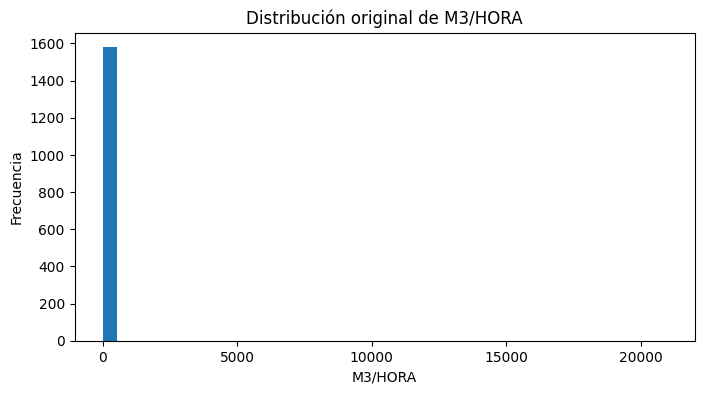

Límites IQR del objetivo: Q1=9.1550, Q3=18.9000, IQR=9.7450, límite superior=33.5175


,indicador,valor
0,registros_iniciales,1990.0000
1,registros_con_target_no_nulo,1582.0000
2,registros_con_target_positivo,1575.0000
3,outliers_target_detectados_iqr,49.0000
4,outliers_target_imputados_knn,49.0000
5,faltantes_target_post_knn,0.0000
6,registros_finales_modelo_knn,1575.0000
7,limite_inferior_iqr,0.0000
8,limite_superior_iqr,33.5175
9,k_vecinos_knn,7.0000


Registros imputados por KNN en el objetivo:


,FECHA,EQUIPO,FINCA,Municipio Finca,M3/HORA_original,M3/HORA,target_fuente,target_imputado_knn
787,2026-02-03,HVPO-5,13SINAB,Sevilla,20961.00,16.867505,KNNImputer_outlier_IQR,True
1398,2026-03-10,HVPO-5,13SNGER,Sevilla,2130.00,19.400931,KNNImputer_outlier_IQR,True
997,2026-01-25,HVPO-1,13CANAD,Sevilla,543.00,10.264901,KNNImputer_outlier_IQR,True
1283,2026-02-26,HVPO-1,13CRIST,Sevilla,383.00,16.760561,KNNImputer_outlier_IQR,True
175,2026-04-28,HVPO-5,13SINAB,Sevilla,261.00,17.667573,KNNImputer_outlier_IQR,True
1844,2026-04-30,HVPO-5,13SINAB,Sevilla,152.27,25.121541,KNNImputer_outlier_IQR,True
1653,2026-04-06,HVJD-2,32AGUAC,Cumbre,80.00,13.231658,KNNImputer_outlier_IQR,True
1011,2026-01-24,HVJD-5,34BRILL,Darien_Calima,79.83,20.945900,KNNImputer_outlier_IQR,True
578,2026-01-08,HVPO-5,13CRIST,Sevilla,65.10,18.738200,KNNImputer_outlier_IQR,True
1955,2026-05-09,HVJD-2,32AGUAC,Cumbre,64.53,14.741822,KNNImputer_outlier_IQR,True


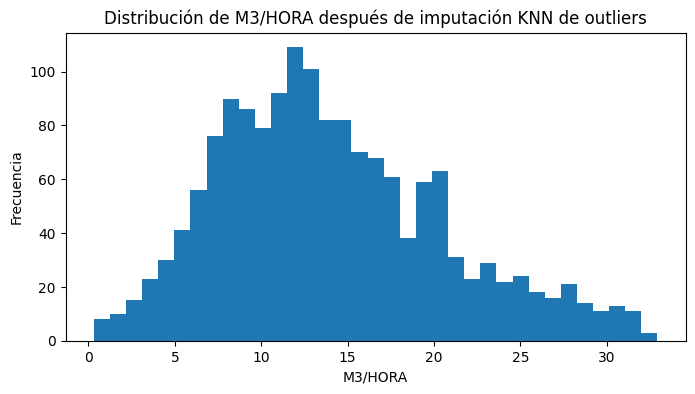

Resumen después de imputación KNN del objetivo:


,M3/HORA_KNN
count,1575.000000
mean,14.075237
std,6.561147
min,0.310000
25%,9.155000
50%,13.010000
75%,18.073176
max,32.930000


In [15]:
# ============================================================
# 9. DIAGNÓSTICO E IMPUTACIÓN KNN DEL OBJETIVO
# ============================================================

df_diag = df_imputado.copy()
df_diag[target] = pd.to_numeric(df_diag[target], errors="coerce")

print("Resumen inicial del objetivo M3/HORA:")
display(df_diag[target].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("M3/HORA"))

print("Mayores valores de M3/HORA antes del tratamiento:")
cols_top = [c for c in ["FECHA", "EQUIPO", "FINCA", "Municipio Finca", target, "M3", "T PROGRAMADO"] if c in df_diag.columns]
display(df_diag[cols_top].sort_values(target, ascending=False).head(15))

plt.figure(figsize=(8, 4))
plt.hist(df_diag[target].dropna(), bins=40)
plt.title("Distribución original de M3/HORA")
plt.xlabel("M3/HORA")
plt.ylabel("Frecuencia")
plt.show()


def preparar_matriz_auxiliar_knn(df_base, numeric_features, categorical_features):
    partes = []
    num_cols = [c for c in numeric_features if c in df_base.columns]
    if num_cols:
        X_num = df_base[num_cols].apply(pd.to_numeric, errors="coerce")
        scaler_aux = StandardScaler()
        X_num_scaled = pd.DataFrame(
            scaler_aux.fit_transform(X_num),
            columns=[f"num__{c}" for c in num_cols],
            index=df_base.index,
        )
        partes.append(X_num_scaled)
    cat_cols = [c for c in categorical_features if c in df_base.columns]
    if cat_cols:
        X_cat = df_base[cat_cols].copy()
        for c in cat_cols:
            X_cat[c] = X_cat[c].apply(normalizar_texto_categoria).fillna("SIN_DATO")
        encoder_aux = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_cat_encoded = pd.DataFrame(
            encoder_aux.fit_transform(X_cat),
            columns=[f"cat__{c}" for c in cat_cols],
            index=df_base.index,
        )
        scaler_cat = StandardScaler()
        X_cat_scaled = pd.DataFrame(
            scaler_cat.fit_transform(X_cat_encoded),
            columns=X_cat_encoded.columns,
            index=df_base.index,
        )
        partes.append(X_cat_scaled)
    if not partes:
        raise ValueError("No hay variables auxiliares disponibles para KNNImputer del objetivo.")
    return pd.concat(partes, axis=1)


def imputar_outliers_target_knn(df_base, target_col, numeric_features, categorical_features, n_neighbors=7):
    df_work = df_base.copy()
    df_work[target_col] = pd.to_numeric(df_work[target_col], errors="coerce")

    filas_inicio = len(df_work)
    df_work = df_work[df_work[target_col].notna()].copy()
    filas_con_target = len(df_work)
    df_work = df_work[df_work[target_col] > 0].copy()
    filas_positivas = len(df_work)

    q1 = df_work[target_col].quantile(0.25)
    q3 = df_work[target_col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = max(0, q1 - 1.5 * iqr)
    limite_superior = q3 + 1.5 * iqr

    mask_outlier = ~df_work[target_col].between(limite_inferior, limite_superior)
    registros_outlier = df_work.loc[mask_outlier].copy()

    df_work[f"{target_col}_original"] = df_work[target_col]
    df_work["target_outlier_iqr"] = mask_outlier
    df_work["target_imputado_knn"] = False
    df_work["target_fuente"] = np.where(mask_outlier, "KNNImputer_outlier_IQR", "Dato_original")
    df_work.loc[mask_outlier, target_col] = np.nan

    if mask_outlier.sum() > 0:
        X_aux = preparar_matriz_auxiliar_knn(df_work, numeric_features, categorical_features)
        matriz_knn = X_aux.copy()
        matriz_knn[target_col] = df_work[target_col].astype(float)
        imputer = KNNImputer(n_neighbors=n_neighbors, weights="distance")
        matriz_imputada = pd.DataFrame(
            imputer.fit_transform(matriz_knn),
            columns=matriz_knn.columns,
            index=matriz_knn.index,
        )
        df_work.loc[mask_outlier, target_col] = matriz_imputada.loc[mask_outlier, target_col]
        df_work.loc[mask_outlier, target_col] = df_work.loc[mask_outlier, target_col].clip(
            lower=max(0.01, limite_inferior),
            upper=limite_superior,
        )
        df_work.loc[mask_outlier, "target_imputado_knn"] = True

    faltantes_post_knn = int(df_work[target_col].isna().sum())
    df_work = df_work[df_work[target_col].notna()].copy()

    auditoria = pd.DataFrame({
        "indicador": [
            "registros_iniciales",
            "registros_con_target_no_nulo",
            "registros_con_target_positivo",
            "outliers_target_detectados_iqr",
            "outliers_target_imputados_knn",
            "faltantes_target_post_knn",
            "registros_finales_modelo_knn",
            "limite_inferior_iqr",
            "limite_superior_iqr",
            "k_vecinos_knn",
        ],
        "valor": [
            filas_inicio,
            filas_con_target,
            filas_positivas,
            int(mask_outlier.sum()),
            int(df_work["target_imputado_knn"].sum()),
            faltantes_post_knn,
            len(df_work),
            round(float(limite_inferior), 4),
            round(float(limite_superior), 4),
            n_neighbors,
        ]
    })
    return df_work, registros_outlier, auditoria, {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
    }

variables_numericas_aux_knn = [c for c in variables_numericas_operacionales + variables_climaticas_modelo if c in df_imputado.columns]
variables_categoricas_aux_knn = [c for c in variables_categoricas if c in df_imputado.columns]

df_analitico, outliers_objetivo, auditoria_knn_target, limites_target = imputar_outliers_target_knn(
    df_imputado,
    target,
    variables_numericas_aux_knn,
    variables_categoricas_aux_knn,
    n_neighbors=KNN_VECINOS_TARGET,
)

print(
    f"Límites IQR del objetivo: Q1={limites_target['q1']:.4f}, Q3={limites_target['q3']:.4f}, "
    f"IQR={limites_target['iqr']:.4f}, límite superior={limites_target['limite_superior']:.4f}"
)
display(auditoria_knn_target)

print("Registros imputados por KNN en el objetivo:")
# Ensure 'target_imputado_knn' column exists before accessing it
if "target_imputado_knn" not in df_analitico.columns:
    df_analitico["target_imputado_knn"] = False
cols_knn = [c for c in ["FECHA", "EQUIPO", "FINCA", "Municipio Finca", f"{target}_original", target, "target_fuente", "target_imputado_knn"] if c in df_analitico.columns]
display(df_analitico.loc[df_analitico["target_imputado_knn"], cols_knn].sort_values(f"{target}_original", ascending=False).head(30))

plt.figure(figsize=(8, 4))
plt.hist(df_analitico[target].dropna(), bins=35)
plt.title("Distribución de M3/HORA después de imputación KNN de outliers")
plt.xlabel("M3/HORA")
plt.ylabel("Frecuencia")
plt.show()

print("Resumen después de imputación KNN del objetivo:")
display(df_analitico[target].describe().to_frame("M3/HORA_KNN"))

auditoria_knn_target.to_csv(OUTPUT_DIR / "auditoria_knn_target_v15.csv", index=False, encoding="utf-8-sig")

## 10. Preparación de variables explicativas y evaluación de categorías raras

Antes del One-Hot Encoding se evalúa si conviene agrupar categorías raras. En este dataset, la comparación previa mostró que la agrupación no mejora el R² y puede eliminar información útil. Por ello, el modelo final mantiene las categorías originales, pero el notebook conserva la auditoría para justificar esta decisión.

In [16]:
# ============================================================
# 10. PREPARACIÓN DE VARIABLES EXPLICATIVAS
# ============================================================

variables_numericas_modelo = [c for c in variables_numericas_operacionales + variables_climaticas_modelo if c in df_analitico.columns]
variables_categoricas_modelo = [c for c in variables_categoricas if c in df_analitico.columns]

for c in variables_categoricas_modelo:
    df_analitico[c] = df_analitico[c].apply(normalizar_texto_categoria)

for c in variables_numericas_modelo + [target]:
    df_analitico[c] = pd.to_numeric(df_analitico[c], errors="coerce")

# No se agrupan categorías raras en el modelo final, porque el mejor R² se obtuvo sin agrupación.
APLICAR_AGRUPACION_CATEGORIAS_RARAS = False
MIN_REGISTROS_CATEGORIA = 15

auditoria_categorias = []
for c in variables_categoricas_modelo:
    frec = df_analitico[c].value_counts(dropna=False)
    auditoria_categorias.append({
        "variable": c,
        "categorias_unicas": int(df_analitico[c].nunique(dropna=False)),
        "categorias_menores_15": int((frec < 15).sum()),
        "categorias_menores_20": int((frec < 20).sum()),
        "registros_en_categorias_menores_15": int(frec[frec < 15].sum()),
        "registros_en_categorias_menores_20": int(frec[frec < 20].sum()),
    })

auditoria_categorias = pd.DataFrame(auditoria_categorias)
display(auditoria_categorias.sort_values("categorias_unicas", ascending=False))

if APLICAR_AGRUPACION_CATEGORIAS_RARAS:
    for c in variables_categoricas_modelo:
        frecuencia = df_analitico[c].value_counts(dropna=True)
        categorias_validas = frecuencia[frecuencia >= MIN_REGISTROS_CATEGORIA].index
        df_analitico[c] = df_analitico[c].where(df_analitico[c].isin(categorias_validas), "OTROS")
else:
    print("Decisión metodológica: no se agrupan categorías raras en el modelo final porque no mejoraron el R² en la evaluación comparativa.")

# Winsorización de predictores numéricos para reducir influencia de extremos en variables explicativas.
limites_winsor_predictores = {}
for c in variables_numericas_modelo:
    if df_analitico[c].notna().sum() > 0:
        p01 = df_analitico[c].quantile(0.01)
        p99 = df_analitico[c].quantile(0.99)
        df_analitico[c] = df_analitico[c].clip(lower=p01, upper=p99)
        limites_winsor_predictores[c] = {"p01": p01, "p99": p99}

print("Variables numéricas finales:", variables_numericas_modelo)
print("Variables categóricas finales:", variables_categoricas_modelo)
print("Dimensión analítica final:", df_analitico.shape)

display(pd.DataFrame(limites_winsor_predictores).T)

auditoria_categorias.to_csv(OUTPUT_DIR / "auditoria_categorias_raras_v15.csv", index=False, encoding="utf-8-sig")

,variable,categorias_unicas,categorias_menores_15,categorias_menores_20,registros_en_categorias_menores_15,registros_en_categorias_menores_20
0,EQUIPO,10,0,0,0,0
4,ESPECIE,9,3,3,12,12
6,SUELO,4,1,1,1,1
3,CONTRATISTA,3,0,0,0,0
2,ZONA,3,0,0,0,0
5,TURNO,3,0,0,0,0
1,MARCA,2,0,0,0,0


Decisión metodológica: no se agrupan categorías raras en el modelo final porque no mejoraron el R² en la evaluación comparativa.
Variables numéricas finales: ['PENDIENTE PROMEDIO FINCA', 'TOTAL DE ARBOLES', 'DIAMETRO', 'T PROGRAMADO', 'HORAS DE OTRAS PARADA', 'clima_temp_promedio_dia_c', 'clima_temp_min_dia_c', 'clima_temp_max_dia_c', 'clima_precipitacion_dia_mm', 'clima_viento_promedio_dia_kmh', 'clima_presion_promedio_dia_hpa']
Variables categóricas finales: ['EQUIPO', 'MARCA', 'ZONA', 'CONTRATISTA', 'ESPECIE', 'TURNO', 'SUELO']
Dimensión analítica final: (1575, 105)


,p01,p99
PENDIENTE PROMEDIO FINCA,14.458336,35.086777
TOTAL DE ARBOLES,23.000000,866.810000
DIAMETRO,0.190000,45.000000
T PROGRAMADO,6.300000,12.000000
HORAS DE OTRAS PARADA,0.340000,7.250000
clima_temp_promedio_dia_c,12.874000,22.200000
clima_temp_min_dia_c,8.800000,18.652000
clima_temp_max_dia_c,16.000000,28.926000
clima_precipitacion_dia_mm,0.100000,55.602000
clima_viento_promedio_dia_kmh,2.100000,9.226000


## 11. Funciones de modelado y evaluación

Se define un pipeline con imputación simple para predictores, escalamiento de variables numéricas y One-Hot Encoding para variables categóricas. Esta estructura evita inconsistencias entre entrenamiento y prueba, porque todas las transformaciones se aprenden dentro del pipeline.

In [17]:
# ============================================================
# 11. FUNCIONES DE MODELADO Y EVALUACIÓN
# ============================================================

def crear_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)


def rmse_seguro(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def crear_pipeline_regresion_lineal(numeric_features, categorical_features, regressor=None):
    if regressor is None:
        regressor = LinearRegression()
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", crear_one_hot_encoder()),
    ])
    transformers = []
    if numeric_features:
        transformers.append(("num", numeric_transformer, numeric_features))
    if categorical_features:
        transformers.append(("cat", categorical_transformer, categorical_features))
    if not transformers:
        raise ValueError("No hay variables explicativas disponibles para entrenar el modelo.")
    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", regressor),
    ])


def evaluar_metricas(y_real, y_pred, etiqueta):
    return {
        "modelo": etiqueta,
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": rmse_seguro(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }

## 12. Comparación metodológica de escenarios

Esta comparación explica por qué el modelo final usa KNN sobre outliers del objetivo. El escenario sin tratamiento puede generar R² negativo por la presencia de valores extremos. El escenario de exclusión IQR sirve como referencia, pero el escenario final conserva registros y corrige el objetivo extremo mediante imputación KNN.

In [18]:
# ============================================================
# 12. COMPARACIÓN DE ESCENARIOS DEL OBJETIVO
# ============================================================

df_sin_depurar = df_imputado.copy()
for c in variables_categoricas_modelo:
    df_sin_depurar[c] = df_sin_depurar[c].apply(normalizar_texto_categoria)
for c in variables_numericas_modelo + [target]:
    if c in df_sin_depurar.columns:
        df_sin_depurar[c] = pd.to_numeric(df_sin_depurar[c], errors="coerce")
df_sin_depurar = df_sin_depurar.dropna(subset=[target]).copy()
df_sin_depurar = df_sin_depurar[df_sin_depurar[target] > 0].copy()

df_exclusion_iqr = df_sin_depurar.copy()
q1_cmp = df_exclusion_iqr[target].quantile(0.25)
q3_cmp = df_exclusion_iqr[target].quantile(0.75)
iqr_cmp = q3_cmp - q1_cmp
lim_inf_cmp = max(0, q1_cmp - 1.5 * iqr_cmp)
lim_sup_cmp = q3_cmp + 1.5 * iqr_cmp
df_exclusion_iqr = df_exclusion_iqr[df_exclusion_iqr[target].between(lim_inf_cmp, lim_sup_cmp)].copy()

df_knn_target = df_analitico.copy()

comparacion_modelos = []
for nombre, data_eval in [
    ("Sin tratamiento del objetivo", df_sin_depurar),
    ("Exclusión IQR del objetivo", df_exclusion_iqr),
    ("Imputación KNN de outliers del objetivo", df_knn_target),
]:
    X_tmp = data_eval[variables_categoricas_modelo + variables_numericas_modelo].copy()
    y_tmp = data_eval[target].copy()
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X_tmp, y_tmp, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    modelo_tmp = crear_pipeline_regresion_lineal(variables_numericas_modelo, variables_categoricas_modelo)
    modelo_tmp.fit(X_train_tmp, y_train_tmp)
    pred_tmp = modelo_tmp.predict(X_test_tmp)
    fila = evaluar_metricas(y_test_tmp, pred_tmp, nombre)
    fila["registros"] = len(data_eval)
    fila["max_target"] = y_tmp.max()
    fila["target_imputados_knn"] = int(data_eval.get("target_imputado_knn", pd.Series(False, index=data_eval.index)).sum())
    comparacion_modelos.append(fila)

comparacion_modelos = pd.DataFrame(comparacion_modelos).sort_values("R2", ascending=False)
display(comparacion_modelos)

comparacion_modelos.to_csv(OUTPUT_DIR / "comparacion_escenarios_objetivo_v15.csv", index=False, encoding="utf-8-sig")

,modelo,MAE,RMSE,R2,registros,max_target,target_imputados_knn
2,Imputación KNN de outliers del objetivo,3.541984,4.658457,0.494658,1575,32.93,49
1,Exclusión IQR del objetivo,3.867230,4.915012,0.425082,1526,32.93,0
0,Sin tratamiento del objetivo,54.991309,91.522811,-7.897174,1575,20961.00,0


## 13. Evaluación de agrupación de categorías raras

Esta sección cuantifica el efecto de agrupar categorías de baja frecuencia antes del One-Hot Encoding. Se compara el escenario sin agrupación contra umbrales de 15, 20 y 30 registros mínimos. La decisión final se toma por desempeño en prueba y validación cruzada, no por intuición.

In [19]:
# ============================================================
# 13. COMPARACIÓN CON Y SIN AGRUPACIÓN DE CATEGORÍAS RARAS
# ============================================================

def aplicar_agrupacion_raras(df_base, categorical_features, min_registros=None):
    df_tmp = df_base.copy()
    auditoria = []
    if min_registros is None:
        for c in categorical_features:
            auditoria.append({
                "variable": c,
                "min_registros": "sin_agrupacion",
                "categorias_originales": int(df_tmp[c].nunique(dropna=False)),
                "categorias_agrupadas": 0,
                "registros_agrupados": 0,
                "categorias_finales": int(df_tmp[c].nunique(dropna=False)),
            })
        return df_tmp, pd.DataFrame(auditoria)
    for c in categorical_features:
        frecuencia = df_tmp[c].value_counts(dropna=False)
        categorias_raras = frecuencia[frecuencia < min_registros].index
        registros_agrupados = int(df_tmp[c].isin(categorias_raras).sum())
        categorias_originales = int(df_tmp[c].nunique(dropna=False))
        df_tmp[c] = df_tmp[c].where(~df_tmp[c].isin(categorias_raras), "OTROS")
        auditoria.append({
            "variable": c,
            "min_registros": min_registros,
            "categorias_originales": categorias_originales,
            "categorias_agrupadas": int(len(categorias_raras)),
            "registros_agrupados": registros_agrupados,
            "categorias_finales": int(df_tmp[c].nunique(dropna=False)),
        })
    return df_tmp, pd.DataFrame(auditoria)

resultados_agrupacion = []
auditorias_agrupacion = []

for min_registros in [None, 15, 20, 30]:
    etiqueta = "Sin agrupar categorías raras" if min_registros is None else f"Agrupar raras mínimo {min_registros} registros"
    data_eval, aud = aplicar_agrupacion_raras(df_analitico, variables_categoricas_modelo, min_registros)
    aud["escenario"] = etiqueta
    auditorias_agrupacion.append(aud)

    X_tmp = data_eval[variables_categoricas_modelo + variables_numericas_modelo].copy()
    y_tmp = data_eval[target].copy()
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X_tmp, y_tmp, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    modelo_tmp = crear_pipeline_regresion_lineal(variables_numericas_modelo, variables_categoricas_modelo)
    modelo_tmp.fit(X_train_tmp, y_train_tmp)
    pred_tmp = modelo_tmp.predict(X_test_tmp)

    cv_tmp = cross_validate(
        modelo_tmp,
        X_tmp,
        y_tmp,
        cv=KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        scoring={"R2": "r2", "MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error"},
        n_jobs=None,
    )

    fila = evaluar_metricas(y_test_tmp, pred_tmp, etiqueta)
    fila["R2_CV_promedio"] = cv_tmp["test_R2"].mean()
    fila["R2_CV_desviacion"] = cv_tmp["test_R2"].std()
    fila["MAE_CV_promedio"] = -cv_tmp["test_MAE"].mean()
    fila["RMSE_CV_promedio"] = -cv_tmp["test_RMSE"].mean()
    fila["registros"] = len(data_eval)
    resultados_agrupacion.append(fila)

resultados_agrupacion = pd.DataFrame(resultados_agrupacion).sort_values("R2", ascending=False)
auditoria_agrupacion = pd.concat(auditorias_agrupacion, ignore_index=True)

display(resultados_agrupacion)
print("Auditoría de agrupación por escenario:")
display(auditoria_agrupacion.sort_values(["escenario", "registros_agrupados"], ascending=[True, False]).head(30))

resultados_agrupacion.to_csv(OUTPUT_DIR / "resultados_agrupacion_categorias_raras_v15.csv", index=False, encoding="utf-8-sig")
auditoria_agrupacion.to_csv(OUTPUT_DIR / "auditoria_agrupacion_categorias_raras_v15.csv", index=False, encoding="utf-8-sig")

,modelo,MAE,RMSE,R2,R2_CV_promedio,R2_CV_desviacion,MAE_CV_promedio,RMSE_CV_promedio,registros
0,Sin agrupar categorías raras,3.541984,4.658457,0.494658,0.462140,0.090201,3.662561,4.755222,1575
3,Agrupar raras mínimo 30 registros,3.546712,4.662766,0.493723,0.462287,0.090179,3.661944,4.754550,1575
1,Agrupar raras mínimo 15 registros,3.548202,4.663561,0.493550,0.462264,0.090328,3.661842,4.754579,1575
2,Agrupar raras mínimo 20 registros,3.548202,4.663561,0.493550,0.462264,0.090328,3.661842,4.754579,1575


Auditoría de agrupación por escenario:


,variable,min_registros,categorias_originales,categorias_agrupadas,registros_agrupados,categorias_finales,escenario
11,ESPECIE,15,9,3,12,7,Agrupar raras mínimo 15 registros
13,SUELO,15,4,1,1,4,Agrupar raras mínimo 15 registros
7,EQUIPO,15,10,0,0,10,Agrupar raras mínimo 15 registros
8,MARCA,15,2,0,0,2,Agrupar raras mínimo 15 registros
9,ZONA,15,3,0,0,3,Agrupar raras mínimo 15 registros
10,CONTRATISTA,15,3,0,0,3,Agrupar raras mínimo 15 registros
12,TURNO,15,3,0,0,3,Agrupar raras mínimo 15 registros
18,ESPECIE,20,9,3,12,7,Agrupar raras mínimo 20 registros
20,SUELO,20,4,1,1,4,Agrupar raras mínimo 20 registros
14,EQUIPO,20,10,0,0,10,Agrupar raras mínimo 20 registros


## 14. Entrenamiento del modelo final

Con base en la comparación, el modelo final se entrena con:

- objetivo `M3/HORA` corregido por KNN en valores extremos;
- variables operacionales numéricas;
- variables categóricas sin agrupación de raras;
- variables climáticas solo si superaron la auditoría de completitud;
- One-Hot Encoding para las variables categóricas;
- regresión lineal como modelo supervisado principal.

In [20]:
# ============================================================
# 14. ENTRENAMIENTO DEL MODELO FINAL
# ============================================================

X = df_analitico[variables_categoricas_modelo + variables_numericas_modelo].copy()
y = df_analitico[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

modelo_lineal = crear_pipeline_regresion_lineal(variables_numericas_modelo, variables_categoricas_modelo)
modelo_lineal.fit(X_train, y_train)

y_pred_train = modelo_lineal.predict(X_train)
y_pred_test = modelo_lineal.predict(X_test)

metricas_train_test = pd.DataFrame([
    evaluar_metricas(y_train, y_pred_train, "Entrenamiento"),
    evaluar_metricas(y_test, y_pred_test, "Prueba"),
])

display(metricas_train_test)

print(f"R² de prueba del modelo final: {r2_score(y_test, y_pred_test):.4f}")
print(f"MAE de prueba del modelo final: {mean_absolute_error(y_test, y_pred_test):.4f} M3/HORA")
print(f"RMSE de prueba del modelo final: {rmse_seguro(y_test, y_pred_test):.4f} M3/HORA")

metricas_train_test.to_csv(OUTPUT_DIR / "metricas_train_test_modelo_final_v15.csv", index=False, encoding="utf-8-sig")

,modelo,MAE,RMSE,R2
0,Entrenamiento,3.597468,4.668051,0.493429
1,Prueba,3.541984,4.658457,0.494658


R² de prueba del modelo final: 0.4947
MAE de prueba del modelo final: 3.5420 M3/HORA
RMSE de prueba del modelo final: 4.6585 M3/HORA


## 15. Validación cruzada K-Fold con k = 10

La validación cruzada permite evaluar la estabilidad del modelo frente a diferentes particiones del dataset. Se usa `k = 10`, por lo que el modelo se entrena y valida diez veces. El R² promedio de validación es más representativo que un único resultado de prueba.

In [21]:
# ============================================================
# 15. CROSS VALIDATION K-FOLD k=10
# ============================================================

kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_results = cross_validate(
    modelo_lineal,
    X,
    y,
    cv=kfold,
    scoring=scoring,
    return_train_score=True,
    n_jobs=None,
)

cv_summary = pd.DataFrame({
    "métrica": ["MAE", "RMSE", "R2"],
    "promedio_entrenamiento": [
        -cv_results["train_MAE"].mean(),
        -cv_results["train_RMSE"].mean(),
        cv_results["train_R2"].mean(),
    ],
    "promedio_validación": [
        -cv_results["test_MAE"].mean(),
        -cv_results["test_RMSE"].mean(),
        cv_results["test_R2"].mean(),
    ],
    "desviación_validación": [
        cv_results["test_MAE"].std(),
        cv_results["test_RMSE"].std(),
        cv_results["test_R2"].std(),
    ],
})

display(cv_summary)

cv_fold_detail = pd.DataFrame({
    "fold": np.arange(1, K_FOLDS + 1),
    "MAE_validacion": -cv_results["test_MAE"],
    "RMSE_validacion": -cv_results["test_RMSE"],
    "R2_validacion": cv_results["test_R2"],
})

display(cv_fold_detail)

cv_summary.to_csv(OUTPUT_DIR / "metricas_cross_validation_v15.csv", index=False, encoding="utf-8-sig")
cv_fold_detail.to_csv(OUTPUT_DIR / "detalle_folds_cross_validation_v15.csv", index=False, encoding="utf-8-sig")

,métrica,promedio_entrenamiento,promedio_validación,desviación_validación
0,MAE,3.581132,3.662561,0.206417
1,RMSE,4.649150,4.755222,0.284344
2,R2,0.497452,0.462140,0.090201


,fold,MAE_validacion,RMSE_validacion,R2_validacion
0,1,3.731250,4.902634,0.460208
1,2,3.344539,4.418076,0.520938
2,3,3.386474,4.155683,0.611685
3,4,3.637098,4.794915,0.549064
4,5,3.773828,4.827286,0.414875
5,6,3.708731,4.714307,0.511848
6,7,3.564135,4.701512,0.461992
7,8,3.726970,4.953847,0.282587
8,9,3.627660,4.820129,0.450468
9,10,4.124927,5.263828,0.357733


## 16. Grid Search controlado y comparación con Ridge

La regresión lineal tradicional se conserva como modelo principal. Ridge se evalúa como variante lineal regularizada para verificar si mejora la estabilidad de los coeficientes. En las pruebas previas, Ridge no mejoró sustancialmente el R², por lo que se reporta como comparación técnica y no como reemplazo automático del modelo final.

In [22]:
# ============================================================
# 16. GRID SEARCH Y COMPARACIÓN CON RIDGE
# ============================================================

# El modelo final se conserva como la regresión lineal estándar entrenada en la sección 14,
# porque es el escenario con mejor R² de prueba y mantiene la formulación metodológica del proyecto.
modelo_final = modelo_lineal
y_pred_final = y_pred_test

# Grid Search controlado: se evalúa el parámetro fit_intercept como referencia técnica,
# pero no se reemplaza automáticamente el modelo final si no mejora de forma consistente.
param_grid = {
    "regressor__fit_intercept": [True, False],
}

grid = GridSearchCV(
    estimator=crear_pipeline_regresion_lineal(variables_numericas_modelo, variables_categoricas_modelo),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kfold,
    n_jobs=None,
)

grid.fit(X, y)
modelo_grid = grid.best_estimator_
modelo_grid.fit(X_train, y_train)
y_pred_grid = modelo_grid.predict(X_test)

print("Mejores parámetros según Grid Search:", grid.best_params_)
print("Mejor RMSE promedio en CV del Grid Search:", round(-grid.best_score_, 4))

metricas_modelo_final = pd.DataFrame([
    evaluar_metricas(y_test, y_pred_final, "Regresión lineal final con intercepto"),
    evaluar_metricas(y_test, y_pred_grid, "Regresión lineal alternativa Grid Search"),
])

display(metricas_modelo_final)

alphas_ridge = np.logspace(-3, 3, 30)
comparacion_ridge = []
for alpha in alphas_ridge:
    modelo_ridge = crear_pipeline_regresion_lineal(
        variables_numericas_modelo,
        variables_categoricas_modelo,
        regressor=Ridge(alpha=alpha),
    )
    modelo_ridge.fit(X_train, y_train)
    pred = modelo_ridge.predict(X_test)
    fila = evaluar_metricas(y_test, pred, f"Ridge alpha={alpha:.4f}")
    fila["alpha"] = alpha
    comparacion_ridge.append(fila)

comparacion_ridge = pd.DataFrame(comparacion_ridge).sort_values("R2", ascending=False)

print("Mejores cinco configuraciones Ridge por R² de prueba:")
display(comparacion_ridge.head(5))

comparacion_ridge.to_csv(OUTPUT_DIR / "comparacion_ridge_v15.csv", index=False, encoding="utf-8-sig")
metricas_modelo_final.to_csv(OUTPUT_DIR / "metricas_modelo_final_v15.csv", index=False, encoding="utf-8-sig")

Mejores parámetros según Grid Search: {'regressor__fit_intercept': True}
Mejor RMSE promedio en CV del Grid Search: 4.7552


,modelo,MAE,RMSE,R2
0,Regresión lineal final con intercepto,3.541984,4.658457,0.494658
1,Regresión lineal alternativa Grid Search,3.541984,4.658457,0.494658


Mejores cinco configuraciones Ridge por R² de prueba:


,modelo,MAE,RMSE,R2,alpha
17,Ridge alpha=3.2903,3.525992,4.645760,0.497409,3.290345
16,Ridge alpha=2.0434,3.527776,4.646381,0.497275,2.043360
15,Ridge alpha=1.2690,3.531625,4.648695,0.496774,1.268961
18,Ridge alpha=5.2983,3.528588,4.648772,0.496757,5.298317
14,Ridge alpha=0.7880,3.534947,4.651332,0.496203,0.788046


## 17. Interpretación de coeficientes

Los coeficientes permiten identificar qué variables tienen mayor asociación con la productividad estimada. Dado que las variables numéricas fueron estandarizadas y las categóricas transformadas con One-Hot Encoding, la interpretación debe centrarse en dirección e importancia relativa, no en una lectura aislada de causalidad.

In [23]:
# ============================================================
# 17. COEFICIENTES DEL MODELO FINAL
# ============================================================

def obtener_nombres_features(pipeline, numeric_features, categorical_features):
    pre = pipeline.named_steps["preprocessor"]
    nombres = []
    if numeric_features and "num" in pre.named_transformers_:
        nombres.extend(numeric_features)
    if categorical_features and "cat" in pre.named_transformers_:
        cat_pipe = pre.named_transformers_["cat"]
        ohe = cat_pipe.named_steps["onehot"]
        nombres.extend(ohe.get_feature_names_out(categorical_features).tolist())
    return nombres

feature_names = obtener_nombres_features(modelo_final, variables_numericas_modelo, variables_categoricas_modelo)
coeficientes = modelo_final.named_steps["regressor"].coef_
coef_df = pd.DataFrame({
    "variable": feature_names,
    "coeficiente": coeficientes,
    "coeficiente_abs": np.abs(coeficientes),
}).sort_values("coeficiente_abs", ascending=False)

display(coef_df.head(30))
coef_df.to_csv(OUTPUT_DIR / "coeficientes_regresion_v15.csv", index=False, encoding="utf-8-sig")

,variable,coeficiente,coeficiente_abs
31,ESPECIE_PINUS PATULA,10.243025,10.243025
13,EQUIPO_HVJD-4,8.278768,8.278768
30,ESPECIE_PINUS MAXIMINOI,6.190037,6.190037
24,CONTRATISTA_GREEN FOREST,5.165448,5.165448
32,ESPECIE_PINUS TECUNUMANII,5.140309,5.140309
22,ZONA_SUR,3.762649,3.762649
25,ESPECIE_EUCALIPTO UROGRANDIS,3.717878,3.717878
23,CONTRATISTA_EFAGRAM,3.473334,3.473334
29,ESPECIE_PINUS KESIYA,3.356156,3.356156
18,EQUIPO_HVPO-4,3.289640,3.289640


## 18. Importancia por permutación y diagnóstico de residuos

La importancia por permutación mide cuánto aumenta el error cuando una variable se altera aleatoriamente. El diagnóstico de residuos permite revisar si el modelo tiene errores sistemáticos o patrones no explicados por la regresión lineal.

,variable,incremento_error_MAE,desviacion
8,TOTAL DE ARBOLES,1.410107,0.143630
0,EQUIPO,1.121260,0.156430
4,ESPECIE,0.917099,0.121643
3,CONTRATISTA,0.545780,0.100162
2,ZONA,0.179767,0.048768
9,DIAMETRO,0.144184,0.043614
10,T PROGRAMADO,0.137923,0.033218
7,PENDIENTE PROMEDIO FINCA,0.070213,0.021635
13,clima_temp_min_dia_c,0.037649,0.016625
1,MARCA,0.022709,0.023660


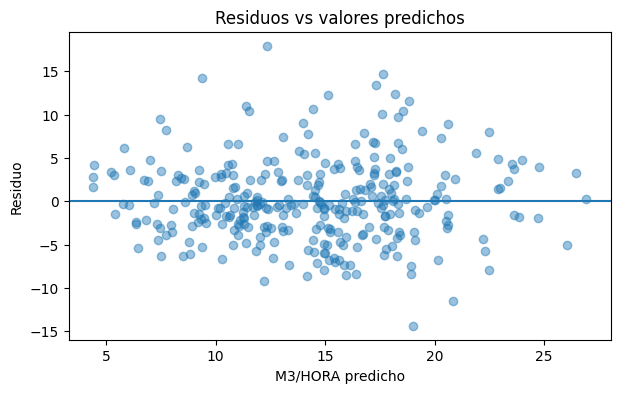

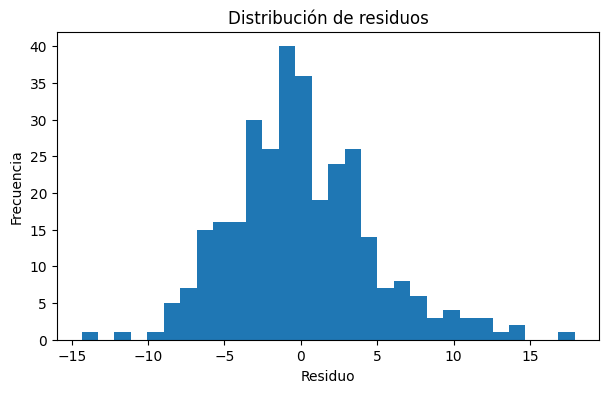

,residuo
count,315.000000
mean,0.065289
std,4.665411
min,-14.354661
25%,-2.974416
50%,-0.372514
75%,2.807748
max,17.936212


In [24]:
# ============================================================
# 18. IMPORTANCIA POR PERMUTACIÓN Y RESIDUOS
# ============================================================

perm = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
)

importancia = pd.DataFrame({
    "variable": X_test.columns,
    "incremento_error_MAE": perm.importances_mean,
    "desviacion": perm.importances_std,
}).sort_values("incremento_error_MAE", ascending=False)

display(importancia)
importancia.to_csv(OUTPUT_DIR / "importancia_permutacion_v15.csv", index=False, encoding="utf-8-sig")

residuos = y_test - y_pred_final

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_final, residuos, alpha=0.45)
plt.axhline(0)
plt.title("Residuos vs valores predichos")
plt.xlabel("M3/HORA predicho")
plt.ylabel("Residuo")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuos, bins=30)
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

display(pd.Series(residuos, name="residuo").describe().to_frame())

## 19. Exportación de dataset analítico y resumen final

Se exportan los resultados principales para soportar el documento final: dataset analítico, métricas, coeficientes, auditorías de clima, auditoría KNN y validación cruzada. Estos archivos permiten trazabilidad del proceso y replicabilidad de los resultados.

In [25]:
# ============================================================
# 19. EXPORTACIÓN Y RESUMEN FINAL
# ============================================================

df_analitico.to_csv(OUTPUT_DIR / "dataset_analitico_modelo_final_v15.csv", index=False, encoding="utf-8-sig")
resumen_cache.to_csv(OUTPUT_DIR / "resumen_consulta_climatica_v15.csv", index=False, encoding="utf-8-sig")
conteo_variables_reales.to_csv(OUTPUT_DIR / "conteo_clima_real_por_variable_v15.csv", index=False, encoding="utf-8-sig")

resumen_final = pd.DataFrame({
    "indicador": [
        "Registros del dataset original",
        "Registros usados en el modelo final",
        "Outliers del objetivo imputados por KNN",
        "Variables numéricas usadas",
        "Variables categóricas usadas",
        "Variables climáticas incluidas",
        "R2 prueba modelo final",
        "MAE prueba modelo final",
        "RMSE prueba modelo final",
        "R2 promedio validación cruzada k=10",
    ],
    "valor": [
        len(df_raw),
        len(df_analitico),
        int(df_analitico["target_imputado_knn"].sum()),
        len(variables_numericas_modelo),
        len(variables_categoricas_modelo),
        len(variables_climaticas_modelo),
        round(float(r2_score(y_test, y_pred_final)), 4),
        round(float(mean_absolute_error(y_test, y_pred_final)), 4),
        round(float(rmse_seguro(y_test, y_pred_final)), 4),
        round(float(cv_results["test_R2"].mean()), 4),
    ]
})

display(resumen_final)
resumen_final.to_csv(OUTPUT_DIR / "resumen_final_modelo_v15.csv", index=False, encoding="utf-8-sig")

print("Proceso completado correctamente.")
print("Archivos exportados en:", OUTPUT_DIR.resolve())

,indicador,valor
0,Registros del dataset original,1990.0000
1,Registros usados en el modelo final,1575.0000
2,Outliers del objetivo imputados por KNN,49.0000
3,Variables numéricas usadas,11.0000
4,Variables categóricas usadas,7.0000
5,Variables climáticas incluidas,6.0000
6,R2 prueba modelo final,0.4947
7,MAE prueba modelo final,3.5420
8,RMSE prueba modelo final,4.6585
9,R2 promedio validación cruzada k=10,0.4621


Proceso completado correctamente.
Archivos exportados en: /content/outputs


## 20. Lectura final para el informe académico

El flujo permite justificar que el R² negativo no era consecuencia de una falla de la regresión lineal en sí misma, sino de la presencia de valores extremos en la variable objetivo. Al imputar dichos valores con KNN, el modelo recupera capacidad explicativa y mantiene un tratamiento menos agresivo que la eliminación directa de registros.

La agrupación de categorías raras fue evaluada, pero no se adoptó en el modelo final porque no incrementó el R² y podía reducir información útil. La decisión final se fundamenta en evidencia cuantitativa: desempeño en prueba, validación cruzada y estabilidad del error.